# Skuld models and heavy binning

This notebook shows why binning near $\Delta\nu$ turns a resolved mode comb into the smooth power excess used by Skuld.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from asterodetect import AsteroScaleSamples, PowerSpectrum, lorentzian_mode_comb, regular_frequency_grid
from asterodetect.asteroscale import ASTERO_SCALE_PARAMETERS

For a self-contained example we construct narrow joint AsteroScale samples. In a real analysis use `AsteroScaleSamples.infer(...)`.

In [3]:
n = 256
rng = np.random.default_rng(12)
values = {name: np.ones(n) for name in ASTERO_SCALE_PARAMETERS}
values.update(
    numax=rng.normal(1000.0, 2.0, n), dnu=rng.normal(100.0, 0.15, n),
    FWHM_env=rng.normal(500.0, 2.0, n), A_env=rng.lognormal(np.log(3.0), 0.08, n),
    A_gran=rng.lognormal(np.log(8.0), 0.08, n),
    b_gran_low=rng.normal(30.0, 1.0, n), b_gran_high=rng.normal(90.0, 2.0, n),
)
samples = AsteroScaleSamples(values)
print(f'Suggested bin width: {samples.suggested_bin_width():.2f} microhertz')

Suggested bin width: 99.99 microhertz


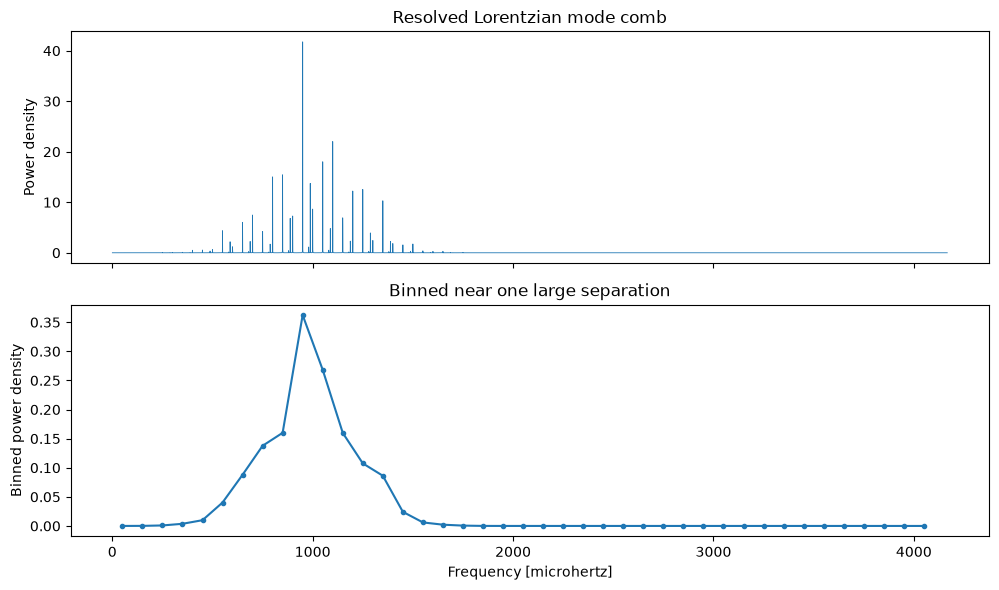

In [4]:
frequency = regular_frequency_grid(27.4, 120.0)
comb = lorentzian_mode_comb(
    frequency, numax=1000.0, dnu=100.0, fwhm_envelope=500.0,
    radial_mode_rms_amplitude=3.0, linewidth=0.2,
)
raw = PowerSpectrum(frequency, np.maximum(comb, 1e-12))
binned = samples.bin_spectrum(raw)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(frequency, comb, lw=0.6)
axes[0].set(ylabel='Power density', title='Resolved Lorentzian mode comb')
axes[1].plot(binned.frequency, binned.power, marker='o', ms=3)
axes[1].set(xlabel='Frequency [microhertz]', ylabel='Binned power density', title='Binned near one large separation')
plt.tight_layout();

The lower panel is the scale on which Skuld fits a Gaussian envelope. The bins are selected once from the independent AsteroScale prediction and remain fixed throughout inference.